1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random
import time

2. Device Configuration and Seed Initialization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# =========================
# Training Hyperparameters
# =========================

batch_size = 128
num_epochs = 15
learning_rate = 0.001

optimizer_name = "Adam"
loss_function_name = "CrossEntropyLoss"

3. Loading Data

In [3]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

classes = train_dataset.classes

4. CNN Model

In [4]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

5. MLP Function

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(32 * 32 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)

        return x

6. Helper Functions

In [6]:
def count_parameters(model):
    """
    Counts trainable model parameters.
    These are learned during training.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_memory_mb(model):
    """
    Estimates model memory based on trainable parameters.
    Assumes each parameter is a 32-bit float, equal to 4 bytes.
    """
    total_params = count_parameters(model)
    return total_params * 4 / (1024 ** 2)


def count_hyperparameters(hparams):
    """
    Counts explicitly defined hyperparameters.
    These are configuration choices set before training.
    """
    return len(hparams)


def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


def train_model(model, model_name, num_epochs=15):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    test_losses = []

    train_accs = []
    test_accs = []

    start_time = time.time()

    for epoch in range(num_epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"{model_name} | Epoch {epoch + 1}/{num_epochs}")
        print(f"Training Loss: {train_loss:.4f}")
        print(f"Training Accuracy: {train_acc:.2f}%")
        print(f"Test Accuracy: {test_acc:.2f}%")
        print("-" * 40)

    end_time = time.time()

    training_time = end_time - start_time

    return {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "training_time": training_time
    }

7. Hyperparameter Dictionaries

In [7]:
cnn_hyperparameters = {
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "learning_rate": learning_rate,
    "optimizer": optimizer_name,
    "loss_function": loss_function_name,
    "conv1_out_channels": 32,
    "conv2_out_channels": 64,
    "conv3_out_channels": 128,
    "conv4_out_channels": 256,
    "kernel_size": 3,
    "padding": 1,
    "batch_norm": True,
    "pooling_type": "MaxPool2d",
    "pooling_kernel_size": 2,
    "fc1_units": 256,
    "output_classes": 10,
    "random_horizontal_flip_probability": 0.5,
    "normalization_mean": (0.5, 0.5, 0.5),
    "normalization_std": (0.5, 0.5, 0.5),
    "seed": seed
}

mlp_hyperparameters = {
    "batch_size": batch_size,
    "num_epochs": num_epochs,
    "learning_rate": learning_rate,
    "optimizer": optimizer_name,
    "loss_function": loss_function_name,
    "input_size": 32 * 32 * 3,
    "fc1_units": 512,
    "fc2_units": 256,
    "fc3_units": 128,
    "output_classes": 10,
    "random_horizontal_flip_probability": 0.5,
    "normalization_mean": (0.5, 0.5, 0.5),
    "normalization_std": (0.5, 0.5, 0.5),
    "seed": seed
}

8. Train CNN and MLP

In [ ]:
cnn_model = ImprovedCNN().to(device)

mlp_model = MLP().to(device)

cnn_results = train_model(
    cnn_model,
    "CNN",
    num_epochs
)

mlp_results = train_model(
    mlp_model,
    "MLP",
    num_epochs
)

9. Comparison Summary

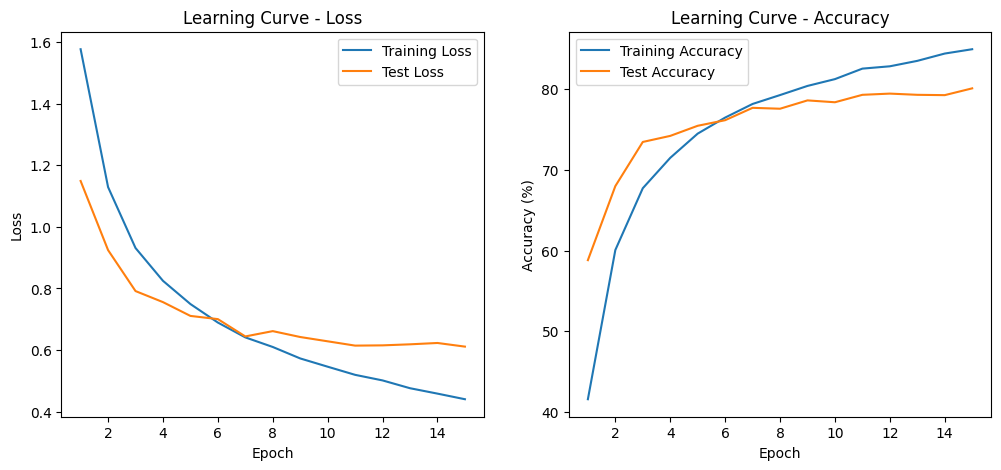

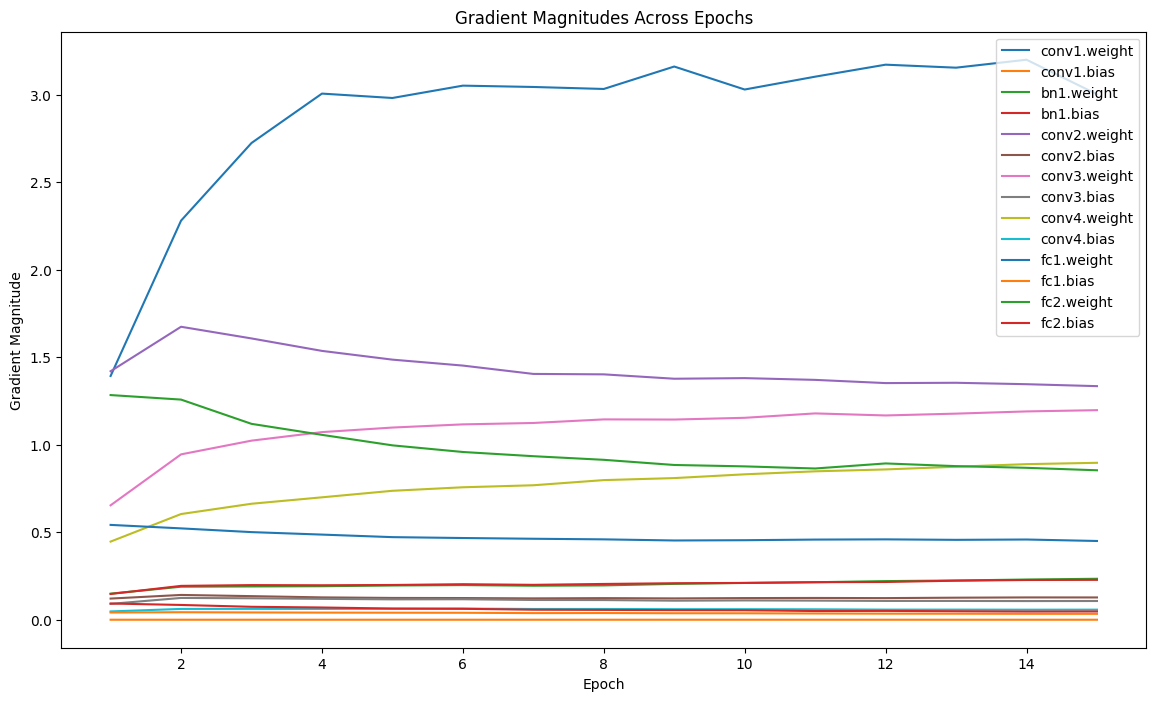

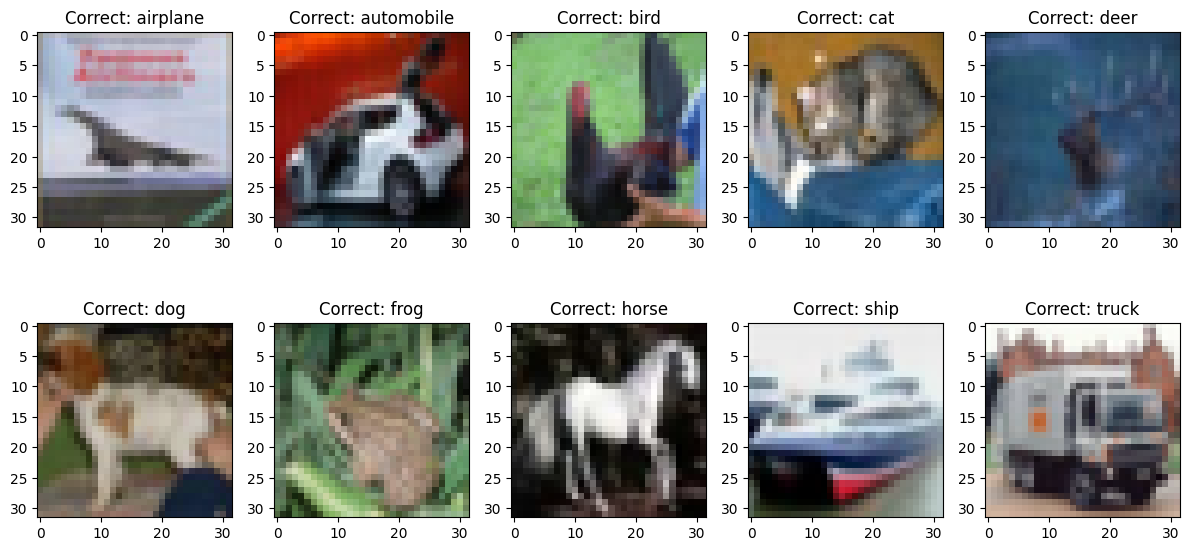

In [ ]:
cnn_params = count_parameters(cnn_model)
mlp_params = count_parameters(mlp_model)

cnn_memory = model_memory_mb(cnn_model)
mlp_memory = model_memory_mb(mlp_model)

cnn_hparam_count = count_hyperparameters(cnn_hyperparameters)
mlp_hparam_count = count_hyperparameters(mlp_hyperparameters)

print("\nFINAL COMPARISON")
print("=" * 60)

print(f"CNN Final Test Accuracy: {cnn_results['test_accs'][-1]:.2f}%")
print(f"MLP Final Test Accuracy: {mlp_results['test_accs'][-1]:.2f}%")

print("-" * 60)

print(f"CNN Parameters: {cnn_params}")
print(f"MLP Parameters: {mlp_params}")

print("-" * 60)

print(f"CNN Hyperparameters Count: {cnn_hparam_count}")
print(f"MLP Hyperparameters Count: {mlp_hparam_count}")

print("-" * 60)

print(f"CNN Model Memory: {cnn_memory:.2f} MB")
print(f"MLP Model Memory: {mlp_memory:.2f} MB")

print("-" * 60)

print(f"CNN Training Time: {cnn_results['training_time']:.2f} seconds")
print(f"MLP Training Time: {mlp_results['training_time']:.2f} seconds")

print("-" * 60)

print("CNN Hyperparameters:")
for key, value in cnn_hyperparameters.items():
    print(f"{key}: {value}")

print("-" * 60)

print("MLP Hyperparameters:")
for key, value in mlp_hyperparameters.items():
    print(f"{key}: {value}")

print("=" * 60)

10. Plot Learning Curves

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, cnn_results["test_accs"], label="CNN Test Accuracy")
plt.plot(epochs, mlp_results["test_accs"], label="MLP Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("CNN vs MLP Test Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, cnn_results["test_losses"], label="CNN Test Loss")
plt.plot(epochs, mlp_results["test_losses"], label="MLP Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN vs MLP Test Loss")
plt.legend()
plt.grid(True)

plt.show()

11. Visualize CNN and MLP Optimized Weights

In [ ]:
def visualize_cnn_weights(model):

    weights = model.conv1.weight.data.cpu()

    fig, axes = plt.subplots(4, 8, figsize=(12, 6))

    for i, ax in enumerate(axes.flat):

        if i < weights.shape[0]:

            filt = weights[i]

            filt = filt.permute(1, 2, 0)

            filt = (filt - filt.min()) / (filt.max() - filt.min())

            ax.imshow(filt)

        ax.axis("off")

    plt.suptitle("CNN Optimized First-Layer Filters")
    plt.show()


visualize_cnn_weights(cnn_model)

# =========================
# Visualize MLP Optimized Weights
# =========================

def visualize_mlp_weights(model):

    weights = model.fc1.weight.data.cpu()

    fig, axes = plt.subplots(4, 8, figsize=(12, 6))

    for i, ax in enumerate(axes.flat):

        if i < 32:

            neuron_weights = weights[i]

            img = neuron_weights.view(3, 32, 32)

            img = img.permute(1, 2, 0)

            img = (img - img.min()) / (img.max() - img.min())

            ax.imshow(img)

        ax.axis("off")

    plt.suptitle("MLP Optimized First-Layer Weights")
    plt.show()


visualize_mlp_weights(mlp_model)